In [1]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
from gtsam import symbolChr, symbolIndex
import gtsam.utils.plot as gtsam_plot
from utilities.utils import kstr, pose2_to_array, rotmat2
from data.data_generator_nonlinear import RobotSimulatorSE2, build_nonlinear_factor_graph, compute_error
from tuning import NonlinearSimParams, NonlinearFactorGraphParams
from utilities.cov_reorder import reorder_covariance_auto, sort_keys_human, elimination_keys

### Create factor graph

In [2]:
# Create simulation configuration
# simParams = NonlinearSimParams(
#     poses=[
#         np.array([0.0, 0.0, 0.0]),  # X0
#         np.array([2.0, 0.0, 0.0]),  # X1
#         np.array([4.0, 0.0, 0.0])   # X2
#     ],
#     landmarks=[
#         np.array([2.0, 2.0]),  # L0
#         np.array([4.0, 2.0]),  # L1
#     ],
#     observations={ # could potentially use max distance to determine this
#         0: [0],     # X0 sees L0
#         1: [0],     # X1 sees L0
#         2: [0,1]    # X2 sees L0 & L1
#     },
#     Q_vec = np.array([0.02, 0.02, 0.01]),   # Process noise
#     R_vec = np.array([0.02, 0.05]),         # Measurement
#     P_x0_vec = np.array([0.01, 0.01, 0.01]) # Prior noise
# )

simParams = NonlinearSimParams(
    poses=[
        np.array([0.0, 0.0, np.pi/2]),  # X0
        np.array([0.0, 2.0, np.pi/2]),  # X1
        np.array([0.0, 4.0, np.pi/2]),  # X2
        np.array([0.0, 6.0, np.pi/2]),  # X3
        np.array([0.0, 8.0, np.pi/2])   # X4

    ],
    landmarks=[
        np.array([2.0, 2.0]),  # L0
        np.array([4.0, 2.0]),  # L1
        np.array([4.0, 4.0]),  # L2
        np.array([6.0, 5.0]),  # L3
        np.array([5.0, 7.0])   # L4
    ],
    observations={ # could potentially use max distance to determine this
        0: [0,1,2],
        1: [0,1,2,3,4],
        2: [0,1,2],
        3: [2,3,4],
        4: [0,1,2,3,4]    
    },
    Q_vec = np.array([0.1, 0.1, 0.05]),     # Process noise
    R_vec = np.array([0.1, 0.05]),          # Measurement
    P_x0_vec = np.array([0.05, 0.05, 0.05]), # Prior noise

    odom_seed=42,
    meas_seed=42,
)

fgParams = NonlinearFactorGraphParams(
    Q_vec = simParams.Q_vec,
    R_vec = simParams.R_vec,
    P_x0_vec = simParams.P_x0_vec
)

simulator = RobotSimulatorSE2(simParams)
sim_data = simulator.simulate()


nfg, initial_estimate = build_nonlinear_factor_graph(
    sim_data, fgParams
)

pose_vars = [X(i) for i in range(len(sim_data['ground_truth']['poses']))]
landmark_vars = [L(i) for i in range(len(sim_data['ground_truth']['landmarks']))]
all_vars = pose_vars + landmark_vars

### Optimization

In [3]:
params = gtsam.LevenbergMarquardtParams()
optimizer = gtsam.LevenbergMarquardtOptimizer(nfg, initial_estimate, params)
result = optimizer.optimize()

for i in range(len(simParams.poses)):
    print(f"X{i}:\n estimated: {result.atPose2(X(i))} true: {sim_data['ground_truth']['poses'][i]}")

for i in range(len(simParams.landmarks)):
    print(f"L{i}:\n estimated: {result.atPoint2(L(i))} true: {sim_data['ground_truth']['landmarks'][i]}")

# Compute and print errors
errors = compute_error(result, sim_data['ground_truth'])
print(f"\nErrors:")
print(f"  Pose RMSE: {errors['pose_rmse']:.4f}")
print(f"  Landmark RMSE: {errors['landmark_rmse']:.4f}")

X0:
 estimated: (-1.32266e-13, -1.66571e-12, 1.5708)
 true: (0, 0, 1.5708)

X1:
 estimated: (-0.0783046, 2.00254, 1.5781)
 true: (0, 2, 1.5708)

X2:
 estimated: (-0.116806, 3.9412, 1.61237)
 true: (0, 4, 1.5708)

X3:
 estimated: (-0.214822, 6.1774, 1.58803)
 true: (0, 6, 1.5708)

X4:
 estimated: (-0.26333, 8.12404, 1.60648)
 true: (0, 8, 1.5708)

L0:
 estimated: [2.02540695 2.15287837] true: [2. 2.]
L1:
 estimated: [4.01794005 2.16189443] true: [4. 2.]
L2:
 estimated: [3.8046718  4.21303485] true: [4. 4.]
L3:
 estimated: [5.78692766 5.36315322] true: [6. 5.]
L4:
 estimated: [4.76549053 7.3506154 ] true: [5. 7.]

Errors:
  Pose RMSE: 0.1944
  Landmark RMSE: 0.3128


### Visualizing graphs

Elimination ordering:
Position 0: l3, l4, x3, l2, l0, x4, x2, x1, x0, l1


Nonlinear Factor Graph:


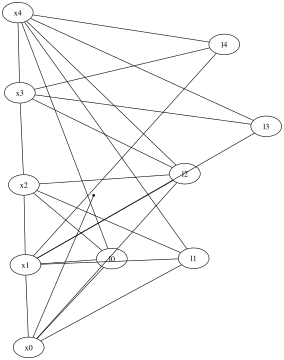

Gaussian Factor Graph (Linearized):


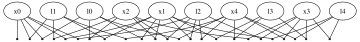

Gaussian Bayes Net:


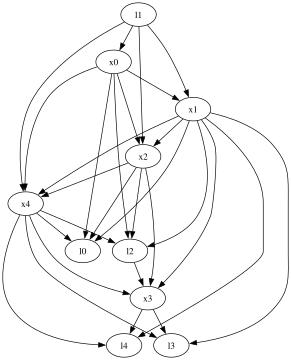

Gaussian Bayes Tree:


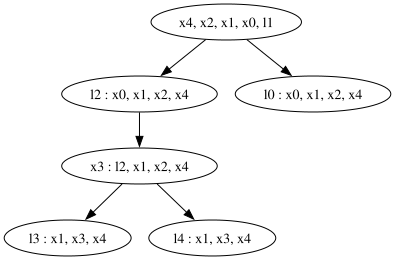

In [5]:
gfg = nfg.linearize(result)

#Convert to Gaussian Bayes Net and Gaussian Bayes Tree
ordering = gtsam.Ordering.ColamdGaussianFactorGraph(gfg)
ordering.print("Elimination ordering:\n")
gbn = gfg.eliminateSequential(ordering) # Gaussian Bayes Net
gbt = gfg.eliminateMultifrontal(ordering) # Gaussian Bayes Tree

print("Nonlinear Factor Graph:")
display(show(nfg, result, binary_edges=True))

print("Gaussian Factor Graph (Linearized):")
display(show(gfg))

print("Gaussian Bayes Net:")
display(show(gbn))

print("Gaussian Bayes Tree:")
display(show(gbt))

### Covariances

The $d$ below is the "square root information vector", as the Bayes net defines the following quadratic, and corresponding Gaussian density, in this case in $\mathbb{R}^6$:

$$
E_{gbn}(x; R, d) \doteq \frac{1}{2} \|Rx - d\|^2
$$

$$
\mathcal{N}_{gbn}(x; R, d) \sim k \exp \{- \frac{1}{2} \|Rx - d\|^2\}
$$

In [6]:
# Method 1: Bayes Net
from utilities.cov_reorder import slice_covariance_for_keys, infer_dims

R, d = gbn.matrix() # Suquare root information matrix (R) and vector (d)
I_from_R = R.T @ R
P_from_R = np.linalg.inv(I_from_R) # sorted by elimination ordering

# Sort the covariance matrix by sorted keys
elim_keys = elimination_keys(ordering)
sorted_keys = sort_keys_human(elim_keys)
dims = infer_dims(elim_keys, values=result)  # Infer dimensions of each variable
P_from_R_sorted = reorder_covariance_auto(P_from_R, elim_keys, sorted_keys, values=result)

print(slice_covariance_for_keys(P_from_R, source_keys=elim_keys, subset_keys=[L(0)], dims=dims))
print(slice_covariance_for_keys(P_from_R_sorted, source_keys=sorted_keys, subset_keys=[L(0)], dims=dims))
ordering.print("Elimination ordering:\n")

[[ 0.02088097 -0.01628903]
 [-0.01628903  0.02035413]]
[[ 0.02088097 -0.01628903]
 [-0.01628903  0.02035413]]
Elimination ordering:
Position 0: l3, l4, x3, l2, l0, x4, x2, x1, x0, l1


#### Covariance Computation Methods in GTSAM

There are two common ways to obtain covariance matrices from a factor graph:

1. **From the Hessian (Information Form)**  
   - The factor graph can be expressed in canonical Gaussian form  
     $
     E(x) = \tfrac{1}{2} x^\top \Lambda x - x^\top \eta + \text{const},
     $  
     where $\Lambda = P^{-1}$ is the **information matrix**.  
   - Calling `gfg.hessian()` constructs this global information matrix \(\Lambda\).  
   - Inverting it yields the full covariance:  
     $
     P_{\text{information}} = \Lambda^{-1}.
     $  
   - Marginal covariances of subsets of variables can then be obtained by slicing the corresponding blocks of $P_{\text{information}}$.  
   - **Advantage:** straightforward, gives full covariance.  
   - **Disadvantage:** requires inverting the entire information matrix (expensive for large problems).  

2. **From Marginalization (Elimination-Based)**  
   - The `Marginals` class computes covariances by **eliminating variables** in the factor graph (e.g., via Cholesky factorization).  
   - This allows extracting only the covariance for a subset of variables without forming the entire $P$.  
   - Calling `marginals.marginalCovariance(key)` gives the covariance for one variable.  
   - Calling `marginals.jointMarginalCovariance(keys)` gives the joint covariance matrix for a set of variables.  
   - **Advantage:** efficient for subsets; avoids computing the full inverse.  
   - **Disadvantage:** requires repeated queries if many different marginals are needed.  

---

**Key Point:** Both methods give the *same result mathematically*. The difference is purely in **how the computation is carried out**:  
- **Hessian inversion:** global, dense, expensive.  
- **Marginals API:** local, on-demand, efficient.  


In [7]:
# Method 2: From marginals
marginals = gtsam.Marginals(nfg, result) # linearized factor graph at result point

joint_marginal = marginals.jointMarginalCovariance(all_vars) # sorted by variable index, X(1) = 8646911284551352321, L(1) = 7782220156096217089
P_from_marginals = joint_marginal.fullMatrix()

# Method 3: From Hessian
I_from_hessian, _ = gfg.hessian()
P_from_hessian = np.linalg.inv(I_from_hessian)

print(np.allclose(P_from_R_sorted, P_from_hessian))  # Should be true

True


## Comparing covariances

Marginals of single variables

In [8]:
# Compare individual marginal covariances
for i, key in enumerate(all_vars, start=1):
    cov_from_joint = slice_covariance_for_keys(P_from_R, source_keys=elim_keys, subset_keys=[key], dims=dims) # Method 1 
    #cov_from_joint = slice_covariance_for_keys(P_from_hessian, source_keys=sorted_keys, subset_keys=[key], dims=dims) # Method 2
    #cov_from_joint = joint_marginal.at(key, key) # Method 3
    cov_from_marg = marginals.marginalCovariance(key)

    print(f"{gtsam.DefaultKeyFormatter(key)}:")
    print("From full joint cov matrix:\n", cov_from_joint)
    print("From marginals:\n", cov_from_marg)
    print("Equal? ->", np.allclose(cov_from_joint, cov_from_marg, atol=1e-10))
    print("-"*50)

# # Compare joint covariance (all poses together)
np.set_printoptions(precision=3, suppress=True)
print("P_from_marginals == P_from_hessian -> ",
      np.allclose(P_from_marginals, P_from_hessian, atol=1e-8))

print("P_from_marginals == P_from_R -> ",
      np.allclose(P_from_marginals, P_from_R, atol=1e-8))

print("P_from_marginals == P_from_R_sorted -> ",
      np.allclose(P_from_marginals, P_from_R_sorted, atol=1e-8))

x0:
From full joint cov matrix:
 [[ 2.50000000e-03  4.46421841e-19  5.69083199e-18]
 [ 4.46421841e-19  2.50000000e-03 -5.28869141e-18]
 [ 5.69083199e-18 -5.28869141e-18  2.50000000e-03]]
From marginals:
 [[ 2.50000000e-03  3.55271368e-19  3.06421555e-18]
 [ 3.55271368e-19  2.50000000e-03 -2.32702746e-17]
 [ 3.06421555e-18 -2.32702746e-17  2.50000000e-03]]
Equal? -> True
--------------------------------------------------
x1:
From full joint cov matrix:
 [[ 0.00929614  0.0013062  -0.00128014]
 [ 0.0013062   0.01777449  0.00590316]
 [-0.00128014  0.00590316  0.00401781]]
From marginals:
 [[ 0.00929614  0.0013062  -0.00128014]
 [ 0.0013062   0.01777449  0.00590316]
 [-0.00128014  0.00590316  0.00401781]]
Equal? -> True
--------------------------------------------------
x2:
From full joint cov matrix:
 [[ 0.01362667 -0.00146597 -0.00202431]
 [-0.00146597  0.05822272  0.01383507]
 [-0.00202431  0.01383507  0.00484235]]
From marginals:
 [[ 0.01362667 -0.00146597 -0.00202431]
 [-0.00146597  0.

Marginals of subset of variables

In [9]:
# Compare individual pose covariances
subset_keys = [X(3), L(0), L(1), L(2)]

cov1 = slice_covariance_for_keys(P_from_R, source_keys=elim_keys, subset_keys=sorted(subset_keys), dims=dims)
cov2 = marginals.jointMarginalCovariance(subset_keys).fullMatrix()   
print("Joint marginal covariance for subset keys equal? ->",
      np.allclose(cov1, cov2, atol=1e-10))

Joint marginal covariance for subset keys equal? -> True


#### Visualizing covariances

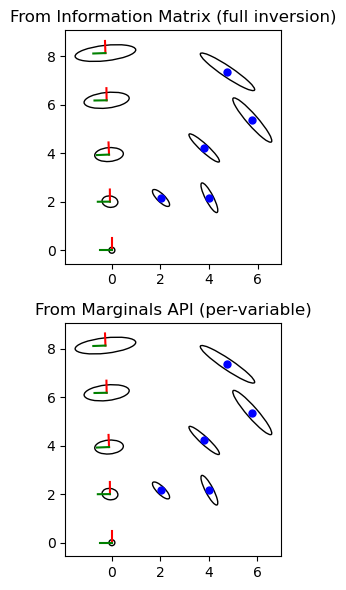

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(22, 6))

for ax, title, cov_source in zip(axs,
    ["From Information Matrix (full inversion)", "From Marginals API (per-variable)"],
    ["joint", "marginals"]
):

    ax.set_aspect('equal')
    ax.set_title(title)

    for i, var in enumerate(all_vars, start=1):

        if cov_source == "joint":
            cov = joint_marginal.at(var, var)
        elif cov_source == "marginals":
            cov = marginals.marginalCovariance(var)

        if kstr(var)[0] == 'X':
            mean = result.atPose2(var)
            gtsam_plot.plot_pose2_on_axes(ax, pose=mean, axis_length=0.5, covariance=cov)
        elif kstr(var)[0] == 'L':
            mean = result.atPoint2(var)
            gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='b', P=cov)

plt.tight_layout()
plt.show()

## Motion and measurement model

In [11]:
"""Rotation used for coordinate transformations of covariance between local and world frame"""
def E(theta):
    M = np.eye(3)
    M[:2,:2] = rotmat2(theta)
    return M

#### Comparing own implemented motion model with GTSAM's Pose2.compose

Note that gtsam operates on the covariance in the local frame while our own implementation operates on the covarince in the global, a rotation is therefore needed to convert between the two.
Also not thate the pose paramterization [x, y, theta] is not
x_i -- [u_j] --> xj

In [34]:
from models.dynamicmodels import OdometrySE2

# Motion model noise parameters of
sigma_x = 0.1
sigma_y = 0.1
sigma_theta = 0.1
Sigma_u = np.diag([sigma_x**2, sigma_y**2, sigma_theta**2])

# Initial pose and covariance (in world frame)
xi = np.array([1, 1, 0.4])
Pi = np.diag([1, 1, 1])

# Odometry increment (defined in the local/body frame of the previous pose, i.e i)
uj = np.array([1, 2, 1.3])

# -------------------------------------------------------
# Prediction using our own motion model (world coordinates)
dyn_model = OdometrySE2(sigma_x=sigma_x, sigma_y=sigma_y, sigma_theta=sigma_theta)
xj, Pj = dyn_model.predict_pose(xi, Pi, uj)

# World-frame Jacobians
Fx = dyn_model.F_x(xi, uj)
Fu = dyn_model.F_u(xi, uj)

# -------------------------------------------------------
# Prediction using GTSAM (local coordinates)
xi_ = gtsam.Pose2(*xi)
uj_ = gtsam.Pose2(*uj)

# Allocate Jacobian buffers (Fortran order is required by GTSAM’s C++ bindings)
Fx_ = np.zeros((3,3), order='F')
Fu_ = np.zeros((3,3), order='F')

Fx__ = np.zeros((3,3), order='F')
Fu__ = np.zeros((3,3), order='F')

# Compose pose and get GTSAM Jacobians
xj_ = xi_.compose(uj_, Fx_, Fu_) # Pose2.compose returns Xj = Xi • Uj
xj__ = xi_.retract(uj, Fx__, Fu__) # Pose2.retract returns Xj = Xi ⊕ uj

# ---------------------------------------------------------------------
# Convert between local (GTSAM) and world (our model) frames
def E(theta):
    """Rotation block for converting between local (body) and world coordinates."""
    c, s = np.cos(theta), np.sin(theta)
    M = np.eye(3)
    M[:2,:2] = np.array([[c, -s],[s, c]])
    return M

Ei = E(xi_.theta())
Ej = E(xj_.theta())
Ej_u = E(uj_.theta())

# Covariance conversions:
# - GTSAM covariances are expressed locally (in body frame)
# - Our model covariances are expressed in world coordinates
#   => Need to map between them using E(theta)
Pi_local = Ei.T @ Pi @ Ei
Pj_local = Fx_ @ Pi_local @ Fx_.T + Fu_ @ Sigma_u @ Fu_.T
Pj_world = Ej @ Pj_local @ Ej.T

# ---------------------------------------------------------------------
# Compare Jacobians (convert world → local convention)
# For Fx: input = world-frame pose, output = local at xj
Fx_local = Ej.T @ Fx @ Ei     # should numerically match Fx_ from GTSAM
Fu_local = Ej.T @ Fu @ Ej_u   # should numerically match Fu_ from GTSAM
# Wrong interepretation but mathimaically same answer: For Fu: input (u) is already expressed in local/body frame → no Ei on RHS (Fu maps from local to world at xi)
# Fu_local = Ei.T @ Fu          


print("Jacobian consistency checks:")
print("Fx_local ≈ Fx_ →", np.allclose(Fx_local, Fx_, atol=1e-9))
print("Fu_local ≈ Fu_ →", np.allclose(Fu_local, Fu_, atol=1e-9))

# ---------------------------------------------------------------------
# Results
print("\nOur motion model prediction:")
print(f"xj: {xj}")
print(f"Pj:\n{Pj}")

print("\nGTSAM Pose2.compose prediction (converted to world frame):")
print(f"xj_: ({xj_.x():.3f}, {xj_.y():.3f}, {xj_.theta():.3f})")
print(f"Pj_world:\n{Pj_world}")

# Print jacobians
print("\nJacobian Fx (Numpy):")
print(Fx)
print("Jacobian Fu (Numpy):")
print(Fu)
print("\nJacobian Fx_ (GTSAM composition):")
print(Fx_)
print("Jacobian Fu_ (GTSAM composition):")
print(Fu_)
print("\nJacobian Fx__ (GTSAM retract):")
print(Fx__)
print("Jacobian Fu__ (GTSAM retract):")
print(Fu__)

Jacobian consistency checks:
Fx_local ≈ Fx_ → True
Fu_local ≈ Fu_ → True

Our motion model prediction:
xj: [1.142 3.232 1.7  ]
Pj:
[[ 5.99  -0.317 -2.232]
 [-0.317  1.03   0.142]
 [-2.232  0.142  1.01 ]]

GTSAM Pose2.compose prediction (converted to world frame):
xj_: (1.142, 3.232, 1.700)
Pj_world:
[[ 5.99  -0.317 -2.232]
 [-0.317  1.03   0.142]
 [-2.232  0.142  1.01 ]]

Jacobian Fx (Numpy):
[[ 1.     0.    -2.232]
 [ 0.     1.     0.142]
 [ 0.     0.     1.   ]]
Jacobian Fu (Numpy):
[[ 0.921 -0.389  0.   ]
 [ 0.389  0.921  0.   ]
 [ 0.     0.     1.   ]]

Jacobian Fx_ (GTSAM composition):
[[ 0.267  0.964  0.429]
 [-0.964  0.267  2.195]
 [ 0.     0.     1.   ]]
Jacobian Fu_ (GTSAM composition):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Jacobian Fx__ (GTSAM retract):
[[ 0.267  0.964  0.429]
 [-0.964  0.267  2.195]
 [ 0.     0.     1.   ]]
Jacobian Fu__ (GTSAM retract):
[[ 0.267  0.964  0.   ]
 [-0.964  0.267  0.   ]
 [ 0.     0.     1.   ]]


In [13]:
x = gtsam.Pose2(1.0, 2.0, np.pi/2)
u = gtsam.Pose2(1, 0, 0)

# See that compose and between are equivalent to * operator
print(gtsam.Pose2.equals(x * u, x.compose(u), tol=1e-9))
print(gtsam.Pose2.equals(x.inverse() * u, x.between(u), tol=1e-9))

True
True


#### Comparing own measurement model with GTSAM's gtsam.RangeBearing...

The Pose2.range() and Pose2.bearing() functions does not provide the jacobians as in the C++ API, so we have to use gtsam.BearingRangeFactor2D instead


In [29]:
from models.measurementmodels import RangeBearing

# Measurement model noise parameters
sigma_range = 0.1
sigma_bearing = 0.1 
R = np.diag([sigma_range**2, sigma_bearing**2])

# Initial pose and landmark
x = np.array([0, 0, np.pi/2])
P = np.diag([1, 1, 1, 1, 1]) # Covariance for [x, y, theta, mx, my]
m = np.array([1.0, 0.0])

# Measurement model
sens_model = RangeBearing(sigma_range, sigma_bearing)
z_pred = sens_model.h_(x, m)
Hx = sens_model.H_x(x, m)
Hm = sens_model.H_m(x, m)

H = np.hstack((Hx, Hm))
P_pred = H @ P @ H.T + R

# GTSAM (Note: gtsam flip the order of range and bearing, i.e. bearing first)
x_ = gtsam.Pose2(*x)
m_ = gtsam.Point2(*m)

# Create a range-bearing measurement
z_range = x_.range(m_)
z_bearing = x_.bearing(m_)

# Noise model (for example)
noise_model = gtsam.noiseModel.Diagonal.Sigmas(np.array([sigma_bearing, sigma_range]))

# Build factor
factor = gtsam.BearingRangeFactor2D(0, 1, z_bearing, z_range, noise_model)

# Values for linearization
values = gtsam.Values()
values.insert(0, x_)
values.insert(1, m_)

# Linearize to get Jacobians (A, b)
linear_factor = factor.linearize(values) # NOTE: when linearizing, GTSAM inbakes the noise model into the factor, meaning jacobian and jacobianUnweighted gives same result...
A, b = linear_factor.jacobianUnweighted()  # Jacobian matrix (weighted by sqrt information even tough called unweighted due to comment above)

Hx_ = A[:, :3]  # Jacobian w.r.t. pose (first 3 columns) 
Hm_ = A[:, 3:]  # Jacobian w.r.t. landmark (last 2 columns)

# swap rows to match our convention (bearing, range) -> (range, bearing)
Hx_ = Hx_[[1,0], :]
Hm_ = Hm_[[1,0], :]
# Dewieght jacobians
Hx_ = np.sqrt(R) @ Hx_
Hm_ = np.sqrt(R) @ Hm_

# Convert jacobians from local (GTSAM) to world frame (our convention)
R_wb = rotmat2(x[2])
Hx_world = Hx_.copy()
Hx_world[0, :2] =  R_wb @ Hx_[0,:2]
Hx_world[1, :2] =  R_wb @ Hx_[1,:2]

print("Measurements:")
print(" range: ", z_pred[0])
print(" bearing: ", z_pred[1])
print("Jacobians from Numpy:")
print(" Hx:\n", Hx)
print(" Hm:\n", Hm)
print("Jacobians from GTSAM:")
print(" Hx_:\n", Hx_)
print(" Hm_:\n", Hm_)
print("Jacobians from GTSAM (converted to world frame):")
print(" Hx_world:\n", Hx_world)


Measurements:
 range:  1.0
 bearing:  -1.5707963267948966
Jacobians from Numpy:
 Hx:
 [[-1. -0.  0.]
 [-0. -1. -1.]]
 Hm:
 [[1. 0.]
 [0. 1.]]
Jacobians from GTSAM:
 Hx_:
 [[-0.  1.  0.]
 [-1. -0. -1.]]
 Hm_:
 [[1. 0.]
 [0. 1.]]
Jacobians from GTSAM (converted to world frame):
 Hx_world:
 [[-1.  0.  0.]
 [ 0. -1. -1.]]


## Caluclation of innovation covariance S

In [ ]:

dyn_model = OdometrySE2(sigma_x=fgParams.sigma_x, 
                        sigma_y=fgParams.sigma_y, 
                        sigma_theta=fgParams.sigma_theta)
sens_model = RangeBearing(sigma_range=fgParams.sigma_range, 
                          sigma_bearing=fgParams.sigma_bearing)

# Define keys for clarity
k = 4 # time step
prev_pose_key = X(k-1)

# Extract all unique landmark keys observed up to and including timestep k-1
landmarks_seen = set()
for t in range(k):  # up to and including k-1
    landmarks_seen.update(simParams.observations[t])

landmark_keys = [L(idx) for idx in sorted(landmarks_seen)] # could be specifed by some gating based in x_pred and m_prev
#landmark_keys = [L(0), L(1), L(2), L(3)] 

state_keys = [prev_pose_key] + landmark_keys

# Get specifed pose and landmarks and put into state vector
x_prev = pose2_to_array(result.atPose2(prev_pose_key))
num_landmarks = len(landmark_keys)
m_prev = np.zeros(2 * num_landmarks)
for i in range(len(landmark_keys)):
    m_prev[2*i:2*(i+1)] = result.atPoint2(landmark_keys[i])
eta_prev = np.hstack((x_prev, m_prev))

# Extract covariance of specified landmarks and pose
P_prev = marginals.jointMarginalCovariance(state_keys).fullMatrix() # return covariance in sorted order
P_prev = reorder_covariance_auto(P_prev, source_keys=sorted(state_keys), target_keys=state_keys, values=result)

# Convert from local to world coordinates for pose covariance
E_prev = np.eye(3 + 2*num_landmarks)
E_prev[:3,:3] = E(x_prev[2])
P_prev = E_prev @ P_prev @ E_prev.T

# State Prediction
u = pose2_to_array(sim_data['measurements']['odometry'][k-1][0]) # k-1 as odometry-measurment
eta_pred, P_pred = dyn_model.predict_state(eta_prev, P_prev, u) 

# Measurment prediction
z_pred, S = sens_model.predict_measurements(eta_pred, P_pred)

# Compare predicted and measured range_bearing measruments
Z = sim_data['measurements']['landmarks'] 
z = Z[k]

# Convert z (actual measurements) to array for easier handling
z_actual_arr = np.array([[float(r), float(b.theta())] for r, b in z])

### Plotting of range-bearing measurements and marginal innovation covariance

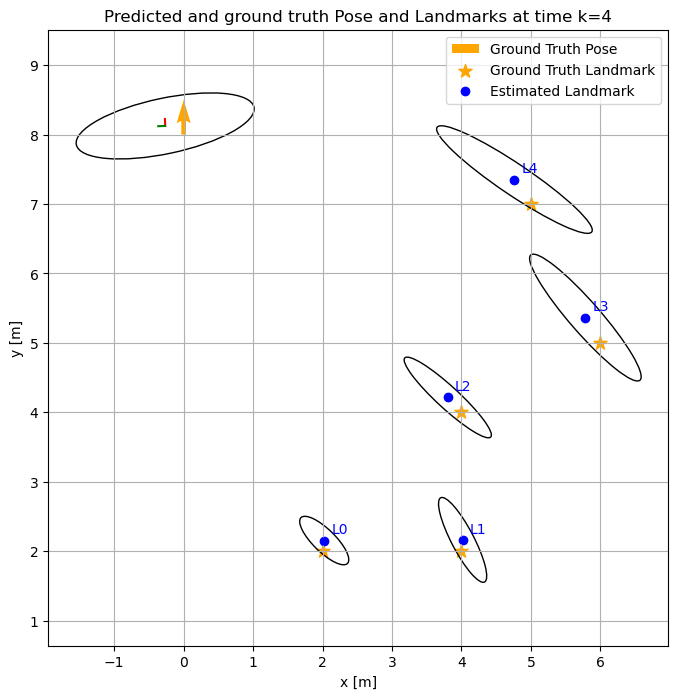

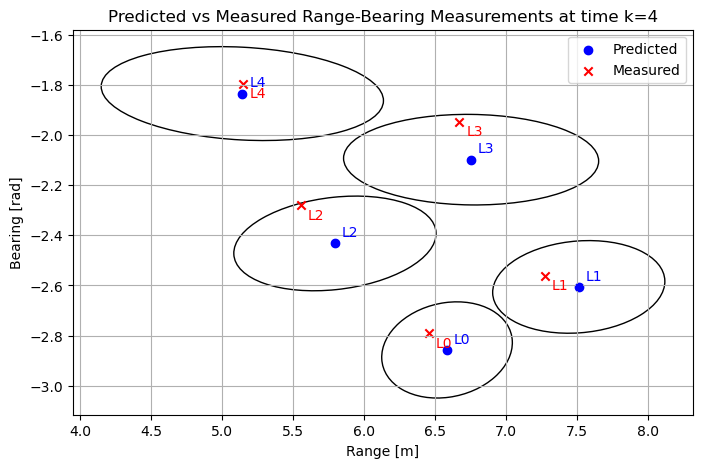

In [16]:
# Plot predicted pose and landmarks
fig, ax = plt.subplots(figsize=(8, 8))

# --- Ground truth pose ---
pose_gt = sim_data['ground_truth']['poses'][k]
if hasattr(pose_gt, 'x'):
    # If it's a gtsam.Pose2 object
    x_gt = pose_gt.x()
    y_gt = pose_gt.y()
    theta_gt = pose_gt.theta()
else:
    # Otherwise assume it's a numpy array [x, y, theta]
    x_gt, y_gt, theta_gt = pose_gt

# Plot ground truth pose as quiver arrow
arrow_len = 0.5  # adjust length for visibility
ax.quiver(
    x_gt, y_gt, np.cos(theta_gt), np.sin(theta_gt),
    angles='xy', scale_units='xy', scale=1/arrow_len,
    color='orange', label='Ground Truth Pose'
)

# Plot ground truth landmarks
for i, lm_key in enumerate(landmark_keys):
    lm_idx = symbolIndex(lm_key)
    lm_gt = sim_data['ground_truth']['landmarks'][lm_idx]
    ax.scatter(lm_gt[0], lm_gt[1], color='orange', marker='*', s=100,
               label='Ground Truth Landmark' if i == 0 else None)
    #ax.annotate(f'L{lm_idx}', (lm_gt[0], lm_gt[1]), textcoords="offset points", xytext=(5,5), ha='left', color='orange')

# --- Predicted pose and landmarks ---
# plot_pose2_on_axes expect covariance in local frame, so we need to convert it back
E_pred = np.eye(3 + 2*num_landmarks)
E_pred[:3,:3] = E(eta_pred[2])
P_pred = E_pred @ P_pred @ E_pred.T

gtsam_plot.plot_pose2_on_axes(ax, pose=result.atPose2(X(k)), covariance=P_pred[:3,:3])
for i, lm_key in enumerate(landmark_keys):
    cov = P_prev[3+2*i:3+2*(i+1), 3+2*i:3+2*(i+1)]
    gtsam_plot.plot_point2_on_axes(ax, point=result.atPoint2(lm_key), linespec='b', P=cov)
    ax.scatter(eta_pred[3+2*i], eta_pred[3+2*i+1], color='blue', marker='o',
               label='Estimated Landmark' if i == 0 else None)
    ax.annotate(f'L{symbolIndex(lm_key)}', (eta_pred[3+2*i], eta_pred[3+2*i+1]), textcoords="offset points",
                xytext=(5,5), ha='left', color='blue')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Predicted and ground truth Pose and Landmarks at time k={k}')
ax.legend(loc='best')
plt.grid(True)
plt.axis('equal')
plt.show()

# Plot predicted and actual measurements for each landmark
fig, ax = plt.subplots(figsize=(8, 5))

# Plot predicted measurements
for i, z_pred_i in enumerate(z_pred): # TODO; add more bulletproof indexing, currently prone to bugs
    ax.scatter(z_pred_i[0], z_pred_i[1], color='blue', marker='o', label='Predicted' if i == 0 else None)
    ax.annotate(f'L{i}', (z_pred_i[0], z_pred_i[1]), textcoords="offset points", xytext=(5,5), ha='left', color='blue')
    gtsam_plot.plot_point2_on_axes(ax, point=z_pred_i, linespec='b', P=S[2*i:2*(i+1), 2*i:2*(i+1)])

# Plot actual measurements
for j, (z_actual_j, obs_landmark_idx) in enumerate(zip(z_actual_arr, simParams.observations[k])):
    ax.scatter(z_actual_j[0], z_actual_j[1], color='red', marker='x', label='Measured' if j == 0 else None)
    ax.annotate(f'L{obs_landmark_idx}', (z_actual_j[0], z_actual_j[1]), textcoords="offset points", xytext=(5,-10), ha='left', color='red')

ax.set_xlabel('Range [m]')
ax.set_ylabel('Bearing [rad]')
ax.set_title(f'Predicted vs Measured Range-Bearing Measurements at time k={k}')
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [17]:
k = 3 # timestep

z = sim_data['measurements']['landmarks']
z3 = z[k-1] 

associations = sim_data['associations']

for i in range(2):
    S_i = S[2*i:2*i+2, 2*i:2*i+2]
    z_i_pred = z_pred[i,:]

for z_j in z3:
    z_range = z_j[0]
    z_bearing = z_j[1]

In [18]:
from utilities.utils import value_dim, value_at

"""Testing value_at and value_dim functions"""

v = gtsam.VectorValues() 
v.insert(X(1), np.array([1.0, 2.0, 0.5]))
v.insert(L(1), np.array([2.0, 3.0]))
print(value_at(v, L(1)))
print(value_dim(value_at(v, L(1))))

x = gtsam.Values()
x.insert(X(1), gtsam.Pose2(1.0, 2.0, 0.5))
x.insert(L(1), gtsam.Point2(2.0, 3.0))
print(value_at(x, X(1)))
print(value_dim(value_at(x, X(1))))

[2. 3.]
2
(1, 2, 0.5)

3
